In [1]:
from pathlib import Path
import numpy as np
from scipy.io import wavfile
import matplotlib.pyplot as plt

In [2]:
def generate_background_noise(
        sample_rate: int = 50000,
        duration_sec: int = 60,
        amplitude: float = 0.5,
        out_dir: Path | str = "../src/waveforms",
    ):
    '''
    Generates constant white-noise background audio (zero-mean uniform noise in [-1, 1], scaled by amplitude).
    Saves a 16-bit mono wav for listening, and a raw F32 binary (mono, no header) for Bonsai MatrixReader.
    '''
    out_dir = Path(out_dir)
    out_dir.mkdir(parents=True, exist_ok=True)

    # Zero-mean uniform white noise in [-1, 1], scaled by amplitude
    noise = np.random.uniform(-1.0, 1.0, int(sample_rate * duration_sec))
    noise_f32 = (noise * amplitude).astype(np.float32)
    noise_i16 = np.clip(noise_f32 * 32767, -32768, 32767).astype(np.int16)

    wavfile.write(out_dir / "background_noise.wav", sample_rate, noise_i16)  # mono, for listening only

    # F32 raw binary (mono, no header) for Bonsai MatrixReader
    noise_f32.tofile(out_dir / "background_noise.bin")

    # Return summary
    return {
        "sample_rate": int(sample_rate),
        "duration_sec": int(duration_sec),
        "n_samples": int(noise_f32.shape[0]),
        "out_dir": str(out_dir),
    }

mean: 2.1640715e-06 min: -0.5 max: 0.5


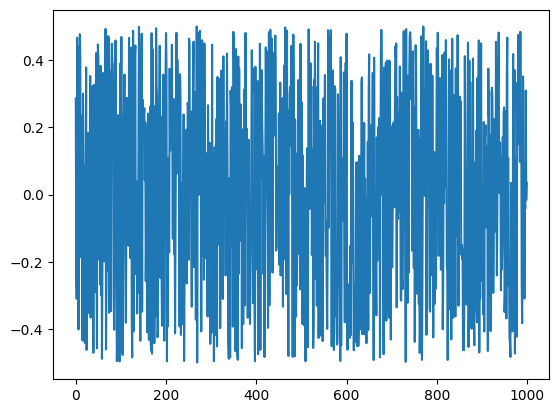

In [4]:
# Sanity check: reload the raw F32 that Bonsai reads and plot the first 1000 samples (should be zero-mean noise)
data = np.fromfile(Path(log["out_dir"]) / "background_noise.bin", dtype=np.float32)
print("mean:", data.mean(), "min:", data.min(), "max:", data.max())
plt.plot(data[:1000])